Configurações Iniciais

In [1]:
#Importar bibliotecas
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
from sklearn.model_selection import train_test_split
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor, VotingRegressor

np.random.seed(42)

#Importar os dados
data = pd.read_csv('../data/dataarea2.csv', header=0)
# Não utilizar variáveis climáticas na previsão
data = data.drop(columns=[
    'Precipitacao_mm', 'Temp_max_C', 'Temp_min_C',
    'Umid_rel_ar', 'Vento_velocidade_ms', 'Vento_rajada_maxima_ms',
], errors='ignore')


In [2]:
#Descartar observações com valores que aparecem menos de 5 vezes
data = data.groupby("guarnição").filter(lambda x: len(x) >= 5)
data = data.groupby("prato_principal_1").filter(lambda x: len(x) >= 5)
data = data.groupby("prato_principal_2").filter(lambda x: len(x) >= 5)
data = data.groupby("sobremesa_1").filter(lambda x: len(x) >= 5)


In [3]:
data_raw_base = data.copy()

# Colunas do dataset ANTES do one-hot — usadas para validar nova_obs mais adiante
colunas_base = data_raw_base.drop(columns=['total']).columns

#Aplicando One Hot Encoding nas variáveis categóricas
data = pd.get_dummies(data, columns=['Mês','Dia_semana','Dia_mês','prato_principal_1',
                                     'prato_principal_2', 'guarnição', 'sobremesa_1'])

# X e y definidos UMA VEZ como DataFrame/Series — não serão reescritos ao longo do notebook
atributos = data.drop(columns=['total']).columns
X = data[atributos]   # DataFrame (preserva feature names)
y = data['total']     # Series

n = len(data)         # número de observações
p = len(atributos)    # número de atributos
print(n, 'observações,', p, 'atributos')


603 observações, 176 atributos


Previsão Intervalar (Conformal Prediction)

In [4]:
def treinar_ensemble_conformal(X, y, alpha=0.05, test_size=0.3, random_state=42):
    """
    Treina o ensemble de conformal prediction e calcula as margens do intervalo.
    """
    nivel_confianca = 1 - alpha

    X_train, X_calib, y_train, y_calib = train_test_split(
        X, y, test_size=test_size, random_state=random_state
    )
    print(f"Treino: {len(X_train)} observações | Calibração: {len(X_calib)} observações")

    # 1. Ensemble de calibração
    ensemble_conformal = VotingRegressor(
        estimators=[('gb', GradientBoostingRegressor(n_estimators=200, random_state=random_state)),
                    ('rf', RandomForestRegressor(n_estimators=200, random_state=random_state))],
        weights=[3, 1]
    )
    ensemble_conformal.fit(X_train, y_train)

    y_calib_pred = ensemble_conformal.predict(X_calib)
    residuos_calib = np.abs(y_calib - y_calib_pred)

    # Dias de transição: primeiros ou últimos 10 dias de semestre
    mascara_transicao  = (X_calib['dias_desde_ultimas_ferias'] <= 10) | (X_calib['dias_ate_ferias'] <= 10)
    residuos_transicao = residuos_calib[mascara_transicao]
    residuos_normais    = residuos_calib[~mascara_transicao]

    margem_transicao = np.quantile(residuos_transicao, nivel_confianca, method='higher')
    margem_normal    = np.quantile(residuos_normais,   nivel_confianca, method='higher')
    margem_total     = np.quantile(residuos_calib,      nivel_confianca, method='higher')

    # 2. Ensemble final, treinado em 100% dos dados
    ensemble = VotingRegressor(
        estimators=[('gb', GradientBoostingRegressor(n_estimators=200, random_state=random_state)),
                    ('rf', RandomForestRegressor(n_estimators=200, random_state=random_state))],
        weights=[3, 1]
    )
    ensemble.fit(X, y)

    print(f"\nCONFORMAL PREDICTION - VALIDAÇÃO:")
    print(f"Margem para Dias de Transição (Início/Fim): ±{margem_transicao:.1f} pessoas ({len(residuos_transicao)} dias analisados)")
    print(f"Margem para Dias Normais: ±{margem_normal:.1f} pessoas ({len(residuos_normais)} dias analisados)")
    print(f"Margem GERAL (sem distinção): ±{margem_total:.1f} pessoas ({len(residuos_calib)} dias analisados)")
    print(f"Mediana GERAL dos resíduos: {np.median(residuos_calib):.1f} pessoas")
    print(f"Média GERAL dos resíduos: {np.mean(residuos_calib):.1f} pessoas")

    return {
        'ensemble': ensemble,
        'ensemble_conformal': ensemble_conformal,
        'X_calib': X_calib,
        'y_calib': y_calib,
        'y_calib_pred': y_calib_pred,
        'margem_transicao': margem_transicao,
        'margem_normal': margem_normal,
        'margem_total': margem_total,
        'nivel_confianca': nivel_confianca,
        'alpha': alpha,
    }


In [5]:
# Treina o ensemble e calcula as margens de conformal prediction (95% de confiança por padrão)
resultado_treino = treinar_ensemble_conformal(X, y, alpha=0.05)


Treino: 422 observações | Calibração: 181 observações

CONFORMAL PREDICTION - VALIDAÇÃO:
Margem para Dias de Transição (Início/Fim): ±115.6 pessoas (56 dias analisados)
Margem para Dias Normais: ±139.7 pessoas (125 dias analisados)
Margem GERAL (sem distinção): ±138.2 pessoas (181 dias analisados)
Mediana GERAL dos resíduos: 32.3 pessoas
Média GERAL dos resíduos: 48.1 pessoas


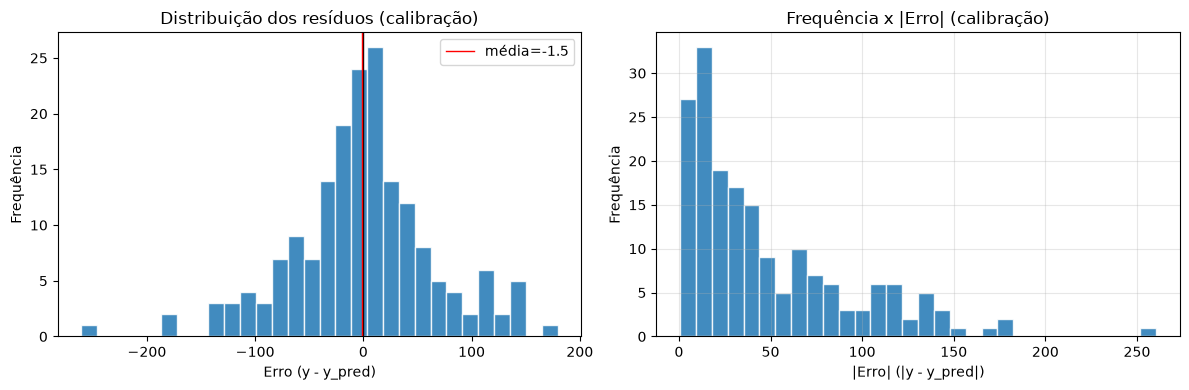

In [6]:
# --- PLOT DO GRÁFICO DOS RESÍDUOS (CALIBRAÇÃO) ---

y_calib      = resultado_treino['y_calib']
y_calib_pred = resultado_treino['y_calib_pred']

# Resíduo com sinal (útil para ver viés): y - y_pred
residuos_assinados_calib = (y_calib.to_numpy() - np.asarray(y_calib_pred))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Histograma dos resíduos (com sinal)
media_res = float(np.mean(residuos_assinados_calib))
axes[0].hist(residuos_assinados_calib, bins=30, alpha=0.85, edgecolor='white')
axes[0].axvline(0, color='black', linewidth=1)
axes[0].axvline(media_res, color='red', linewidth=1, label=f'média={media_res:.1f}')
axes[0].set_title('Distribuição dos resíduos (calibração)')
axes[0].set_xlabel('Erro (y - y_pred)')
axes[0].set_ylabel('Frequência')
axes[0].legend()

# Frequência x |erro|
abs_erros = np.abs(residuos_assinados_calib)
counts, edges = np.histogram(abs_erros, bins=30)
centers = (edges[:-1] + edges[1:]) / 2
widths = np.diff(edges)
axes[1].bar(centers, counts, width=widths, alpha=0.85, edgecolor='white', align='center')
axes[1].set_title('Frequência x |Erro| (calibração)')
axes[1].set_xlabel('|Erro| (|y - y_pred|)')
axes[1].set_ylabel('Frequência')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


In [7]:
def validar_nova_obs(nova_obs_dict, colunas_base):
    """
    Confere se as chaves de nova_obs batem com as colunas reais do dataset
    (antes do one-hot encoding).
    """
    colunas_base_set = set(colunas_base)
    chaves = set(nova_obs_dict.keys())

    invalidas = sorted(chaves - colunas_base_set)
    faltando  = sorted(colunas_base_set - chaves)

    if invalidas:
        raise ValueError(
            "As seguintes colunas em nova_obs não existem no dataset (confira nomes/typos): "
            f"{invalidas}\n\nColunas válidas disponíveis: {sorted(colunas_base_set)}"
        )

    if faltando:
        print(f"Atenção: colunas do dataset não informadas em nova_obs (serão preenchidas com 0 no one-hot): {faltando}")

    return True


In [8]:
def prever_intervalo(nova_obs_dict, resultado_treino, colunas_base, atributos, y):
    """
    Valida, codifica e prevê o intervalo de confiança para uma observação nova.
    """

    validar_nova_obs(nova_obs_dict, colunas_base)

    nova_obs = pd.DataFrame(nova_obs_dict)
    nova_obs_processed = pd.get_dummies(nova_obs).reindex(columns=atributos, fill_value=0)

    ensemble         = resultado_treino['ensemble']
    margem_transicao = resultado_treino['margem_transicao']
    margem_normal    = resultado_treino['margem_normal']
    nivel_confianca  = resultado_treino['nivel_confianca']

    # Mesmo critério usado em treinar_ensemble_conformal para separar os resíduos
    dias_desde_ultimas_ferias = nova_obs_dict['dias_desde_ultimas_ferias'][0]
    dias_ate_ferias           = nova_obs_dict['dias_ate_ferias'][0]
    is_transicao = (dias_desde_ultimas_ferias <= 10) or (dias_ate_ferias <= 10)

    if is_transicao:
        margem_usada = margem_transicao
        tipo_dia = "Transição (início/fim de férias)"
    else:
        margem_usada = margem_normal
        tipo_dia = "Normal"

    pred_central = ensemble.predict(nova_obs_processed)[0]
    limite_inf   = max(y.min(), pred_central - margem_usada)
    limite_sup   = pred_central + margem_usada

    print(f"\nPrevisão Central: {int(round(pred_central))} pessoas esperadas")
    print(f"\nTipo de dia (para escolha da margem): {tipo_dia}")
    print(f"\nIntervalo de Confiança ({nivel_confianca*100:.1f}%):")
    print(f"  Limite Inferior: {int(round(limite_inf))} pessoas")
    print(f"  Previsão: {int(round(pred_central))} pessoas")
    print(f"  Limite Superior: {int(round(limite_sup))} pessoas")
    print(f"\n  Amplitude: {int(round(limite_sup - limite_inf))} pessoas")
    print(f"  Margem usada: ±{int(round(margem_usada))} pessoas")
    print(f"\nGarantias Estatísticas:")
    print(f"  Nível de Confiança: {nivel_confianca*100:.1f}%")
    print(f"  Calibração: {len(resultado_treino['y_calib'])} observações")

    return {
        'pred_central': pred_central,
        'limite_inf': limite_inf,
        'limite_sup': limite_sup,
        'tipo_dia': tipo_dia,
        'margem_usada': margem_usada,
    }


In [9]:
#--- PREDIÇÃO FOCADA COM CONFORMAL PREDICTION ---

nova_obs_dict = {
    'Ano': [2025],                    # ano da previsão
    'Dia_mês': [25],
    'Dia_semana': ['ter'],
    'Mês': [3],
    'prato_principal_1': ['lasanha à bolonhesa'],
    'prato_principal_2': ['curry de legumes'],
    'guarnição': ['legumes sautê'],
    'sobremesa_1': ['goiabada'],
    'letivo': [1],
    'vespera_nao_letivo': [0],
    'pos_nao_letivo': [0],
    'dias_desde_ultimas_ferias': [90],
    'dias_ate_ferias': [90],
    'feriado': [0],
    'ferias': [0],
    'vespera_feriado': [0],
    'pos_feriado': [0],
    'dias_desde_inicio_ferias': [0],
    'dias_ate_feriado': [90],
}

resultado_previsao = prever_intervalo(nova_obs_dict, resultado_treino, colunas_base, atributos, y)



Previsão Central: 617 pessoas esperadas

Tipo de dia (para escolha da margem): Normal

Intervalo de Confiança (95.0%):
  Limite Inferior: 478 pessoas
  Previsão: 617 pessoas
  Limite Superior: 757 pessoas

  Amplitude: 279 pessoas
  Margem usada: ±140 pessoas

Garantias Estatísticas:
  Nível de Confiança: 95.0%
  Calibração: 181 observações


In [10]:
# Lista as observações (dias) com maior e menor |resíduo|
# IMPORTANTE: usa a base pré-one-hot (data_raw_base) para garantir consistência de índice com X_calib.

X_calib      = resultado_treino['X_calib']
y_calib_pred = resultado_treino['y_calib_pred']

data_raw = data_raw_base.copy()

# Seleciona exatamente as linhas usadas na calibração (mesmo índice)
out = data_raw.loc[X_calib.index].copy()

# Alinha a predição por índice (robusto a qualquer reordenação)
pred_series = pd.Series(y_calib_pred, index=X_calib.index, name='Predição')
out['Predição'] = pred_series.loc[out.index].to_numpy()

# Resíduo (com sinal): Total - Predição
out['Resíduo'] = out['total'].to_numpy() - out['Predição'].to_numpy()
out['Resíduo_abs'] = np.abs(out['Resíduo'])

piores20   = out.sort_values('Resíduo_abs', ascending=False).head(20)
melhores20 = out.sort_values('Resíduo_abs', ascending=True).head(20)

cols_chave = [
    'Ano','Mês','Dia_mês','Dia_semana',
    'total','Predição','Resíduo','Resíduo_abs',
    'letivo', 'feriado', 'ferias', 'vespera_nao_letivo','pos_nao_letivo',
    'dias_desde_ultimas_ferias', 'dias_desde_inicio_ferias', 'dias_ate_feriado','dias_ate_ferias',
    'Precipitacao_mm','Temp_max_C','Temp_min_C','Umid_rel_ar',
    'Vento_velocidade_ms','Vento_rajada_maxima_ms',
    'prato_principal_1','prato_principal_2','guarnição','sobremesa_1',
]
cols_chave = [c for c in cols_chave if c in out.columns]

print("\nTop 20 dias com maior resíduo absoluto (|Total - ŷ|) na calibração:\n")
display(piores20[cols_chave] if cols_chave else piores20)

print("\nTop 20 dias com menor resíduo absoluto (|Total - ŷ|) na calibração:\n")
display(melhores20[cols_chave] if cols_chave else melhores20)



Top 20 dias com maior resíduo absoluto (|Total - ŷ|) na calibração:



,Ano,Mês,Dia_mês,Dia_semana,total,Predição,Resíduo,Resíduo_abs,letivo,feriado,...,vespera_nao_letivo,pos_nao_letivo,dias_desde_ultimas_ferias,dias_desde_inicio_ferias,dias_ate_feriado,dias_ate_ferias,prato_principal_1,prato_principal_2,guarnição,sobremesa_1
644,2025,10,14,ter,418.0,678.494359,-260.494359,260.494359,1,0,...,0,0,71,0,13,59,Lasanha bolonhesa,Lasanha de PVT,Repolho,Doce de leite
552,2025,6,24,ter,587.0,407.534934,179.465066,179.465066,1,0,...,0,0,120,0,52,13,Carne moída,Hamburguer de PVT,Ervilha parmentier,Bombom
350,2024,6,19,qua,336.0,511.595945,-175.595945,175.595945,1,0,...,0,0,114,0,57,13,Filé de peixe,Grãos com queijo,Couve-flor,Cocada
412,2024,9,9,seg,409.0,581.531770,-172.531770,172.531770,1,0,...,0,1,35,0,33,94,Frango empanado,Suflê de legumes,Creme de milho,Barra de cereais
424,2024,9,24,ter,812.0,663.521761,148.478239,148.478239,1,0,...,0,0,50,0,18,79,Hamburguer,Hamburguer de lentilha,Macarrão,Picolé
13,2023,3,14,ter,714.0,571.887609,142.112391,142.112391,1,0,...,0,0,1,0,20,123,Frango empanado,Bife de grão de bico,Creme de milho,Arroz doce
301,2024,4,18,qui,790.0,649.298280,140.701720,140.701720,1,0,...,0,0,52,0,13,75,Estrogonofe de carne,Estrogonofe de grão de bico,Batata palha,Pé de moça
28,2023,3,31,sex,519.0,379.317976,139.682024,139.682024,1,0,...,0,0,18,0,3,106,Bife,Lasanha de queijo,Couve-flor,Gelatina
329,2024,5,22,qua,504.0,643.187302,-139.187302,139.187302,1,0,...,0,0,86,0,8,41,Lombo,Ovo frito,Couve,Pão de mel
67,2023,5,22,seg,704.0,565.784613,138.215387,138.215387,1,0,...,0,1,70,0,17,54,Linguiça,Grão de bico,Virado,Bolinho



Top 20 dias com menor resíduo absoluto (|Total - ŷ|) na calibração:



,Ano,Mês,Dia_mês,Dia_semana,total,Predição,Resíduo,Resíduo_abs,letivo,feriado,...,vespera_nao_letivo,pos_nao_letivo,dias_desde_ultimas_ferias,dias_desde_inicio_ferias,dias_ate_feriado,dias_ate_ferias,prato_principal_1,prato_principal_2,guarnição,sobremesa_1
94,2023,6,28,qua,569.0,569.598418,-0.598418,0.598418,1,0,...,0,0,107,0,47,17,Filé de frango,Lasanha de queijo,Cenoura,Gelatina
591,2025,8,9,sáb,0.0,0.701659,-0.701659,0.701659,1,0,...,1,0,5,0,6,125,Bife,Tomate recheado,Polenta,Arroz doce
579,2025,7,26,sáb,0.0,1.165328,-1.165328,1.165328,0,0,...,1,1,0,19,20,0,Carne em cubos,Xadrez de grão de bico,Ervilha parmentier,Barra de cereais
143,2023,8,26,sáb,0.0,2.108665,-2.108665,2.108665,1,0,...,1,0,19,0,9,117,Carne em cubos,Bife de PVT,Purês,Torrone
670,2025,11,28,sex,253.0,255.606712,-2.606712,2.606712,1,0,...,0,0,116,0,0,14,Pernil,Ovo frito,Chuchu,Flan de baunilha
509,2025,4,24,qui,559.0,556.215957,2.784043,2.784043,1,0,...,0,0,59,0,7,74,Filé de peixe,Xadrez de grão de bico,Purês,Mousse de limão
196,2023,11,9,qui,502.0,498.716459,3.283541,3.283541,1,0,...,0,0,94,0,6,42,Carne em cubos,Almôndega de aveia,Macarrão,Manjar
181,2023,10,18,qua,552.0,548.127219,3.872781,3.872781,1,0,...,0,0,72,0,10,64,Frango assado,Cassoulet,Polenta,Flan de baunilha
675,2025,12,12,sex,74.0,69.817319,4.182681,4.182681,0,0,...,1,0,0,0,0,0,Peixe frito,Batatalhoada,Cenoura,Bolinho
638,2025,10,8,qua,571.0,575.420423,-4.420423,4.420423,1,0,...,0,0,65,0,19,65,Carne em cubos,Bife de feijão,Mandioca,Bombom
